# YOLOv5 Meter Recognition v2
## Дообучение с фокусом на класс точки (.)

**Что меняется по сравнению с v1:**
1. Добавляются 3 новых датасета с LCD-точками (всего ~5 датасетов)
2. Анализ распределения классов до и после объединения
3. Class weighting для точки (увеличенный вес в loss)
4. Input size 416×416 вместо 320×320 (точка занимает больше пикселей)
5. Усиленная augmentation для мелких объектов
6. Экспорт в tflite fp32 для Android

## 1. Подготовка окружения

In [ ]:
# Клонируем YOLOv5
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt -q
!pip install roboflow -q

import torch
print('CUDA:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

Cloning into 'yolov5'...
remote: Enumerating objects: 17968, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 17968 (delta 95), reused 51 (delta 51), pack-reused 17849 (from 3)
Receiving objects: 100% (17968/17968), 17.10 MiB | 19.38 MiB/s, done.
Resolving deltas: 100% (12226/12226), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.1 MB/s eta 0:00:00
CUDA: True
GPU: NVIDIA L4


## 2. Скачиваем датасеты

**Старые (которые уже использовались в v1):**
- `meter-digits-frvqn` (v2) — 0-9, ~1900 фото
- `water-meter-reading` (v1) — 0-9 + counter + liters, ~3000 фото
- `ocr-digivault` (v10) — `.`, 0-9, kwh, ~7000 фото (тут точка, но её мало)

**Новые (для усиления точки):**
- `digital-meter-electricity` (Seeed Studio) — 543 фото электросчётчиков
- `7-segment-digit-number-display` (labmonitor) — 698 фото
- `lcd-0yegr` (o1) — 2661 фото LCD-цифр

In [ ]:
from roboflow import Roboflow

API_KEY = "D4ywoMtYFGkqNIWWcc57"
rf = Roboflow(api_key=API_KEY)

# === СТАРЫЕ ДАТАСЕТЫ ===
print("📥 Скачиваем датасет 1/6: meter-digits-frvqn...")
dataset1 = rf.workspace("meter-i5vud").project("meter-digits-frvqn").version(2).download("yolov5")

print("📥 Скачиваем датасет 2/6: water-meter-reading...")
dataset2 = rf.workspace("new-workspace-j7ezo").project("water-meter-reading").version(1).download("yolov5")

print("📥 Скачиваем датасет 3/6: ocr-digivault...")
dataset3 = rf.workspace("work-n51jy").project("ocr-digivault").version(10).download("yolov5")

# === НОВЫЕ ДАТАСЕТЫ С LCD-ТОЧКАМИ ===
# ВАЖНО: после скачивания нужно проверить data.yaml каждого и сопоставить классы.
# Скрипт ниже выведет все классы — посмотри на них и обнови class_map

print("📥 Скачиваем датасет 4/6: digital-meter-electricity (Seeed Studio)...")
try:
    dataset4 = rf.workspace("seeed-studio-dbk14").project("digital-meter-electricity").version(1).download("yolov5")
except Exception as e:
    print(f"⚠️ Не удалось скачать: {e}. Попробуй другую версию вручную.")
    dataset4 = None

print("📥 Скачиваем датасет 5/6: 7-segment-digit-number-display...")
try:
    dataset5 = rf.workspace("labmonitor").project("7-segment-digit-number-display").version(1).download("yolov5")
except Exception as e:
    print(f"⚠️ Не удалось скачать: {e}. Попробуй другую версию вручную.")
    dataset5 = None

print("📥 Скачиваем датасет 6/6: lcd-0yegr (o1)...")
try:
    dataset6 = rf.workspace("o1").project("lcd-0yegr").version(1).download("yolov5")
except Exception as e:
    print(f"⚠️ Не удалось скачать: {e}. Попробуй другую версию вручную.")
    dataset6 = None

print("\n✅ Скачивание завершено!")

📥 Скачиваем датасет 1/6: meter-digits-frvqn...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to meter-digits-2 in yolov5pytorch:: 100%|██████████| 3802/3802 [00:00<00:00, 10526.40it/s]

📥 Скачиваем датасет 2/6: water-meter-reading...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Water-Meter-Reading-1 in yolov5pytorch:: 100%|██████████| 6082/6082 [00:00<00:00, 8371.61it/s]


...


Extracting Dataset Version Zip to 7-segment-digit-number-&-display-1 in yolov5pytorch:: 100%|██████████| 1408/1408 [00:00<00:00, 11277.14it/s]

📥 Скачиваем датасет 6/6: lcd-0yegr (o1)...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to lcd-1 in yolov5pytorch:: 100%|██████████| 61/61 [00:00<00:00, 9839.73it/s]


✅ Скачивание завершено!


## 3. Проверка классов в каждом датасете

**Важный шаг!** Roboflow-датасеты могут иметь разный порядок классов. Скрипт ниже читает `data.yaml` каждого датасета и выводит список классов. По нему мы понимаем, какие классы куда мапить.

In [ ]:
import os
import yaml

datasets_info = [
    ("meter-digits-frvqn", dataset1),
    ("water-meter-reading", dataset2),
    ("ocr-digivault", dataset3),
    ("digital-meter-electricity", dataset4),
    ("7-segment-digit-number-display", dataset5),
    ("lcd-0yegr", dataset6),
]

for name, ds in datasets_info:
    if ds is None:
        print(f"⏭️  {name}: пропущен (не скачался)")
        continue
    yaml_path = os.path.join(ds.location, 'data.yaml')
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        names = data.get('names', [])
        print(f"\n📋 {name} ({ds.location}):")
        for i, cls in enumerate(names):
            print(f"    {i}: {cls}")
    else:
        print(f"⚠️  {name}: data.yaml не найден")


📋 meter-digits-frvqn (/content/yolov5/meter-digits-2):
    0: 0
    1: 1
    2: 2
    3: 3
    4: 4
    5: 5
    6: 6
    7: 7
    8: 8
    9: 9

📋 water-meter-reading (/content/yolov5/Water-Meter-Reading-1):
    0: 0
    1: 1
    2: 2
    3: 3
    4: 4
    5: 5
    6: 6
    7: 7
    8: 8
    9: 9
    10: counter
    11: liters

📋 ocr-digivault (/content/yolov5/OCR(DigiVault)-10):
    0: .
    1: 0
    2: 1
    3: 2
    4: 3
    5: 4
    6: 5
    7: 6
    8: 7
    9: 8
    10: 9
    11: kwh

📋 digital-meter-electricity (/content/yolov5/digital-meter-electricity-1):
    0: 0
    1: 1
    2: 2
    3: 3
    4: 4
    5: 5
    6: 6
    7: 7
    8: 8
    9: 9

📋 7-segment-digit-number-display (/content/yolov5/7-segment-digit-number-&-display-1):
    0: -
    1: .
    2: 0
    3: 1
    4: 2
    5: 3
    6: 4
    7: 5
    8: 6
    9: 7
    10: 8
    11: 9
    12: screen

📋 lcd-0yegr (/content/yolov5/lcd-1):
    0: -
    1: .
    2: 0
    3: 1
    4: 2
    5: 3
    6: 5
    7: 6
    8: 7
    9

## 4. Маппинг классов и объединение датасетов

**Финальная схема классов:**
- 0-9: цифры (одноимённые из всех датасетов)
- 10: liters (counter)
- 11: `.` (точка/decimal)

**После выполнения предыдущей ячейки** — обнови `class_map` ниже для новых датасетов, если порядок классов не совпадает с указанным.

In [ ]:
import shutil
from pathlib import Path

# Конфигурация: для каждого датасета задаём class_map из old_id → new_id.
# None означает 'пропустить класс' (выбросить из разметки).
# ⚠️ Перед запуском проверь class_map по выводу предыдущей ячейки!

datasets_config = {
    "meter-digits": {
        "dataset": dataset1,
        "class_map": {
            0: 0, 1: 1, 2: 2, 3: 3, 4: 4,
            5: 5, 6: 6, 7: 7, 8: 8, 9: 9
        }
    },
    "water-meter": {
        "dataset": dataset2,
        "class_map": {
            0: 0, 1: 1, 2: 2, 3: 3, 4: 4,
            5: 5, 6: 6, 7: 7, 8: 8, 9: 9,
            10: None,  # 'counter' — ИСКЛЮЧАЕМ
            11: 10     # 'liters' → класс 10
        }
    },
    "ocr-digivault": {
        "dataset": dataset3,
        "class_map": {
            0: 11,  # '.' → класс 11
            1: 0, 2: 1, 3: 2, 4: 3, 5: 4,
            6: 5, 7: 6, 8: 7, 9: 8, 10: 9,
            11: None  # 'kwh' — ИСКЛЮЧАЕМ
        }
    },
    "digital-meter-electricity": {
        "dataset": dataset4,
        "class_map": {
            0: 0, 1: 1, 2: 2, 3: 3, 4: 4,
            5: 5, 6: 6, 7: 7, 8: 8, 9: 9
        }
    },
    "7-segment-digit": {
        "dataset": dataset5,
        "class_map": {
            0: None,  # '-' — ИСКЛЮЧАЕМ (знак минуса не нужен)
            1: 11,    # '.' → класс 11
            2: 0, 3: 1, 4: 2, 5: 3, 6: 4,
            7: 5, 8: 6, 9: 7, 10: 8, 11: 9,
            12: None  # 'screen' — ИСКЛЮЧАЕМ
        }
    },
    "lcd-digits": {
        "dataset": dataset6,
        "class_map": {
            0: None,  # '-' — ИСКЛЮЧАЕМ
            1: 11,    # '.' → класс 11
            2: 0, 3: 1, 4: 2,  # ВНИМАНИЕ: в этом датасете НЕТ класса '4'!
            5: 3, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9
            # перепроверь по data.yaml — у тебя в выводе есть скачок: 5: 3, 6: 5 (без 4)
            # это значит, что в самом датасете нет цифры 4
        }
    },
}

# Создаём выходную папку
output_dir = "/content/combined_dataset_v2"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
for split in ['train', 'valid', 'test']:
    os.makedirs(f"{output_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{output_dir}/{split}/labels", exist_ok=True)

file_counter = 0

for dataset_name, config in datasets_config.items():
    ds = config["dataset"]
    if ds is None:
        print(f"⏭️  Пропускаем {dataset_name} (датасет недоступен)")
        continue

    dataset_path = ds.location
    class_map = config["class_map"]

    print(f"\n📂 Обрабатываем {dataset_name} из {dataset_path}")

    for split in ['train', 'valid', 'test']:
        img_dir = f"{dataset_path}/{split}/images"
        lbl_dir = f"{dataset_path}/{split}/labels"

        if not os.path.exists(img_dir):
            print(f"  ⚠️  {split}/images не найден, пропускаем")
            continue

        images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

        for img_file in images:
            new_img_name = f"{dataset_name}_{file_counter:06d}{Path(img_file).suffix}"
            shutil.copy(
                f"{img_dir}/{img_file}",
                f"{output_dir}/{split}/images/{new_img_name}"
            )

            lbl_file = Path(img_file).stem + '.txt'
            lbl_path = f"{lbl_dir}/{lbl_file}"

            if os.path.exists(lbl_path):
                new_lbl_name = Path(new_img_name).stem + '.txt'
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()

                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    old_class = int(parts[0])
                    if old_class in class_map:
                        new_class = class_map[old_class]
                        if new_class is None:
                            continue
                        parts[0] = str(new_class)
                        new_lines.append(' '.join(parts) + '\n')

                if new_lines:
                    with open(f"{output_dir}/{split}/labels/{new_lbl_name}", 'w') as f:
                        f.writelines(new_lines)

            file_counter += 1

        print(f"  ✅ {split}: {len(images)} изображений")

print(f"\n🎉 Всего объединено {file_counter} изображений!")


📂 Обрабатываем meter-digits из /content/yolov5/meter-digits-2
  ✅ train: 1327 изображений
  ✅ valid: 380 изображений
  ✅ test: 188 изображений

📂 Обрабатываем water-meter из /content/yolov5/Water-Meter-Reading-1
  ✅ train: 2563 изображений
  ✅ valid: 315 изображений
  ✅ test: 157 изображений

📂 Обрабатываем ocr-digivault из /content/yolov5/OCR(DigiVault)-10
  ✅ train: 2998 изображений
  ✅ valid: 415 изображений
  ✅ test: 162 изображений

📂 Обрабатываем digital-meter-electricity из /content/yolov5/digital-meter-electricity-1
  ✅ train: 462 изображений
  ✅ valid: 81 изображений
  ⚠️  test/images не найден, пропускаем

📂 Обрабатываем 7-segment-digit из /content/yolov5/7-segment-digit-number-&-display-1
  ✅ train: 537 изображений
  ✅ valid: 121 изображений
  ✅ test: 40 изображений

📂 Обрабатываем lcd-digits из /content/yolov5/lcd-1
  ✅ train: 20 изображений
  ✅ valid: 5 изображений
  ✅ test: 3 изображений

🎉 Всего объединено 9774 изображений!


## 5. 🔍 АНАЛИЗ: сколько меток каждого класса в итоговом датасете?

Это **критически важная** ячейка. Она покажет реальное распределение классов после объединения. Если точек (класс 11) очень мало — поймём, нужны ли ещё датасеты или достаточно того что есть.

📊 Распределение классов в объединённом датасете:

Class             Train      Valid       Test      Total
-------------------------------------------------------
0 (0):     11042       1799        777      13618
1 (1):      4886        787        353       6026
2 (2):      4134        715        287       5136
3 (3):      3448        568        246       4262
4 (4):      3369        554        260       4183
5 (5):      3401        598        232       4231
6 (6):      3123        539        239       3901
7 (7):      2886        535        212       3633
8 (8):      3080        533        230       3843
9 (9):      3047        510        221       3778
10 (liters):      2520        309        156       2985
11 (.):      1629        230         96       1955


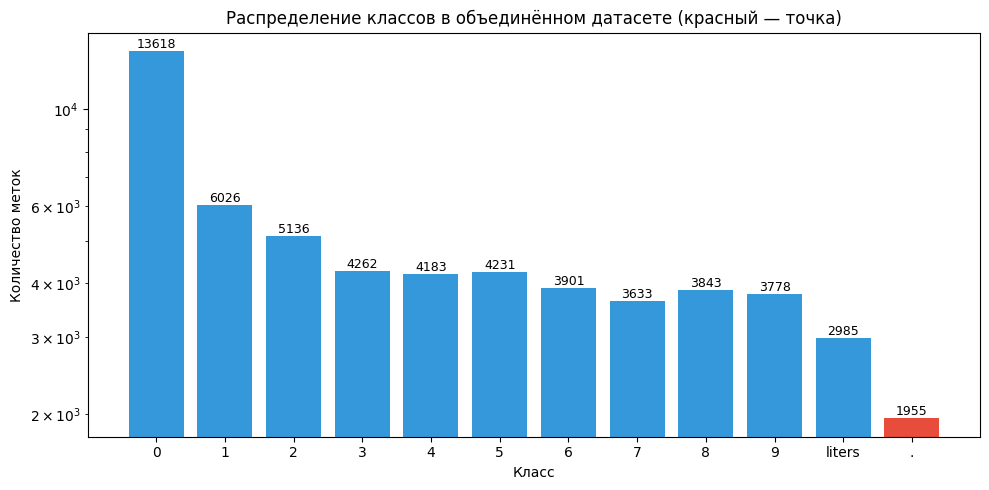


⚖️  Class weights (для balancing):
  Class 0 (0): 1.00
  Class 1 (1): 2.26
  Class 2 (2): 2.65
  Class 3 (3): 3.19
  Class 4 (4): 3.25
  Class 5 (5): 3.22
  Class 6 (6): 3.49
  Class 7 (7): 3.75
  Class 8 (8): 3.54
  Class 9 (9): 3.60
  Class 10 (liters): 4.56
  Class 11 (.): 6.96

💡 Точка (класс 11) встречается в 1955 раз против 13618 для нуля.
   Дисбаланс: 1:6
   ⚠️  Точек умеренно. Class weighting должен помочь.


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "liters", "."]

stats = {}
for split in ['train', 'valid', 'test']:
    counter = Counter()
    lbl_dir = f"{output_dir}/{split}/labels"
    if not os.path.exists(lbl_dir):
        continue
    for lbl_file in os.listdir(lbl_dir):
        with open(f"{lbl_dir}/{lbl_file}") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    counter[int(parts[0])] += 1
    stats[split] = counter

print("📊 Распределение классов в объединённом датасете:\n")
print(f"{'Class':<12} {'Train':>10} {'Valid':>10} {'Test':>10} {'Total':>10}")
print("-" * 55)
totals = Counter()
for class_id in range(12):
    train_c = stats.get('train', {}).get(class_id, 0)
    valid_c = stats.get('valid', {}).get(class_id, 0)
    test_c = stats.get('test', {}).get(class_id, 0)
    total = train_c + valid_c + test_c
    totals[class_id] = total
    marker = "  ← ВНИМАНИЕ" if class_id == 11 and total < 500 else ""
    print(f"{class_id} ({class_names[class_id]}):{train_c:>10} {valid_c:>10} {test_c:>10} {total:>10}{marker}")

# Гистограмма
fig, ax = plt.subplots(figsize=(10, 5))
ids = list(range(12))
vals = [totals[i] for i in ids]
colors = ['#3498db' if i != 11 else '#e74c3c' for i in ids]
ax.bar([class_names[i] for i in ids], vals, color=colors)
ax.set_xlabel('Класс')
ax.set_ylabel('Количество меток')
ax.set_title('Распределение классов в объединённом датасете (красный — точка)')
ax.set_yscale('log')
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=100)
plt.show()

# Расчёт class weights (для loss-функции)
max_count = max(totals.values())
weights = {i: max_count / (totals[i] + 1) for i in range(12)}
print("\n⚖️  Class weights (для balancing):")
for class_id in range(12):
    print(f"  Class {class_id} ({class_names[class_id]}): {weights[class_id]:.2f}")

print(f"\n💡 Точка (класс 11) встречается в {totals[11]} раз против {totals[0]} для нуля.")
print(f"   Дисбаланс: 1:{totals[0] // (totals[11] + 1)}")
if totals[11] < 500:
    print("   ⚠️  Точек МАЛО. Рекомендую добавить ещё датасеты или сделать augmentation.")
elif totals[11] < 2000:
    print("   ⚠️  Точек умеренно. Class weighting должен помочь.")
else:
    print("   ✅ Точек достаточно.")

## 6. Усиление класса точки через oversampling

Если точек мало — копируем картинки с точкой в train несколько раз с разными именами. Это даёт классу больше веса при обучении, не меняя архитектуру модели.

In [ ]:
# Oversampling: копируем картинки, содержащие класс 11 (точка), N раз.
# Это самый эффективный способ при бесплатном Colab без сложных augmentation-библиотек.

OVERSAMPLE_FACTOR = 4  # копировать каждую картинку с точкой 4 раза

train_images_dir = f"{output_dir}/train/images"
train_labels_dir = f"{output_dir}/train/labels"

images_with_dot = []
for lbl_file in os.listdir(train_labels_dir):
    with open(f"{train_labels_dir}/{lbl_file}") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5 and int(parts[0]) == 11:
                images_with_dot.append(lbl_file)
                break

print(f"📌 Найдено {len(images_with_dot)} картинок с точкой в train")
print(f"🔁 Каждая будет скопирована {OVERSAMPLE_FACTOR} раз")

oversample_counter = 0
for lbl_file in images_with_dot:
    base = Path(lbl_file).stem
    # Находим оригинальное изображение
    img_file = None
    for ext in ['.jpg', '.jpeg', '.png']:
        candidate = f"{train_images_dir}/{base}{ext}"
        if os.path.exists(candidate):
            img_file = candidate
            img_ext = ext
            break
    if img_file is None:
        continue

    for i in range(OVERSAMPLE_FACTOR):
        new_base = f"{base}_dot_oversample_{i}"
        shutil.copy(img_file, f"{train_images_dir}/{new_base}{img_ext}")
        shutil.copy(f"{train_labels_dir}/{lbl_file}", f"{train_labels_dir}/{new_base}.txt")
        oversample_counter += 1

print(f"✅ Создано {oversample_counter} дополнительных копий")

# Пересчитываем статистику после oversampling
counter_after = Counter()
for lbl_file in os.listdir(train_labels_dir):
    with open(f"{train_labels_dir}/{lbl_file}") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                counter_after[int(parts[0])] += 1

print("\n📊 Распределение в train после oversampling:")
for class_id in range(12):
    print(f"  Class {class_id} ({class_names[class_id]}): {counter_after[class_id]}")

📌 Найдено 1598 картинок с точкой в train
🔁 Каждая будет скопирована 4 раз
✅ Создано 6392 дополнительных копий

📊 Распределение в train после oversampling:
  Class 0 (0): 19446
  Class 1 (1): 9166
  Class 2 (2): 7822
  Class 3 (3): 6924
  Class 4 (4): 6773
  Class 5 (5): 6653
  Class 6 (6): 6023
  Class 7 (7): 5338
  Class 8 (8): 5620
  Class 9 (9): 6067
  Class 10 (liters): 2520
  Class 11 (.): 8145


## 7. data.yaml для обучения

In [ ]:
data_yaml = f"""
train: {output_dir}/train/images
val: {output_dir}/valid/images
test: {output_dir}/test/images

nc: 12
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'liters', '.']
"""

with open(f"{output_dir}/data.yaml", 'w') as f:
    f.write(data_yaml)

print(f"✅ Записан {output_dir}/data.yaml")
print(data_yaml)

✅ Записан /content/combined_dataset_v2/data.yaml

train: /content/combined_dataset_v2/train/images
val: /content/combined_dataset_v2/valid/images
test: /content/combined_dataset_v2/test/images

nc: 12
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'liters', '.']



## 8. Кастомные hyperparameters для мелких объектов

Создаём файл гиперпараметров с усиленной augmentation для мелких объектов. Ключевые отличия от дефолтных:
- `scale: 0.7` (вместо 0.5) — больше масштабирования, модель видит цифры в разных размерах
- `mosaic: 1.0` — обязательно (4 картинки в одной, помогает с мелкими объектами)
- `copy_paste: 0.1` — copy-paste augmentation
- `cls: 0.7` (вместо 0.5) — увеличенный вес классификационного loss

In [ ]:
hyp_yaml = """
lr0: 0.01
lrf: 0.01
momentum: 0.937
weight_decay: 0.0005
warmup_epochs: 3.0
warmup_momentum: 0.8
warmup_bias_lr: 0.1
box: 0.05
cls: 0.7
cls_pw: 1.0
obj: 1.0
obj_pw: 1.0
iou_t: 0.20
anchor_t: 4.0
fl_gamma: 0.0
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 5.0
translate: 0.1
scale: 0.7
shear: 2.0
perspective: 0.0
flipud: 0.0
fliplr: 0.0
mosaic: 1.0
mixup: 0.1
copy_paste: 0.1
"""

with open("/content/hyp_meter.yaml", 'w') as f:
    f.write(hyp_yaml)

print("✅ Записан /content/hyp_meter.yaml")
print("\nКомментарии:")
print("  • cls: 0.7 — увеличенный вес классификации (точка vs цифра)")
print("  • scale: 0.7 — больше масштабирования (полезно для мелких объектов)")
print("  • flipud/fliplr: 0 — не переворачиваем цифры (1 не должна стать зеркальной)")
print("  • degrees: 5 — небольшой поворот для разнообразия")
print("  • mosaic + mixup + copy_paste — все три augmentation активны")

✅ Записан /content/hyp_meter.yaml

Комментарии:
  • cls: 0.7 — увеличенный вес классификации (точка vs цифра)
  • scale: 0.7 — больше масштабирования (полезно для мелких объектов)
  • flipud/fliplr: 0 — не переворачиваем цифры (1 не должна стать зеркальной)
  • degrees: 5 — небольшой поворот для разнообразия
  • mosaic + mixup + copy_paste — все три augmentation активны


## 9. Обучение

Ключевые изменения по сравнению с v1:
- **`--img 416`** (вместо 320) — точка займёт ~1.7x больше пикселей
- **`--hyp /content/hyp_meter.yaml`** — кастомная augmentation
- **`--weights yolov5s.pt`** — стартуем с pretrained
- **`--epochs 200`** — меньше эпох (T4 устаёт), при необходимости продолжим

In [ ]:
!python train.py \
  --img 416 \
  --batch 64 \
  --epochs 200 \
  --data {output_dir}/data.yaml \
  --weights yolov5s.pt \
  --hyp /content/hyp_meter.yaml \
  --name meter_combined_v2 \
  --patience 30 \
  --save-period 10 \
  --cache ram

Выходные данные были обрезаны до нескольких последних строк (5000).
    189/199      6.53G    0.02963    0.02409    0.01613        887        416:   1% 2/224 [00:00<00:53,  4.17it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
    189/199      6.53G     0.0294    0.02535    0.01623        882        416:   1% 3/224 [00:00<00:54,  4.09it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
    189/199      6.53G    0.02946    0.02521    0.01626        886        416:   2% 4/224 [00:00<00:54,  4.07it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
    189/199      6.5

## 10. Валидация и метрики по классам

Особенно важно посмотреть **precision/recall для класса 11 (точка)** — это покажет, насколько успешно мы решили проблему.

In [ ]:
!python val.py \
  --weights runs/train/meter_combined_v2/weights/best.pt \
  --data {output_dir}/data.yaml \
  --img 416 \
  --task test \
  --verbose

val: data=/content/combined_dataset_v2/data.yaml, weights=['runs/train/meter_combined_v2/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)

Fusing layers... 
Model summary: 157 layers, 7042489 parameters, 0 gradients, 15.9 GFLOPs
test: Scanning /content/combined_dataset_v2/test/labels... 550 images, 0 backgrounds, 0 corrupt: 100% 550/550 [00:00<00:00, 9629.60it/s]
test: New cache created: /content/combined_dataset_v2/test/labels.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 18/18 [00:05<00:00,  3.10it/s]
                   all        550       3309      0.946      0.905      0.946      0.632
 

## 11. Тест на твоих проблемных фото

Загрузи свои фото (те 5 что показывали проблему) и проверь, как модель работает теперь.

In [ ]:
# Загрузка тестовых фото
from google.colab import files
import os

os.makedirs('/content/test_photos', exist_ok=True)
print("📤 Загрузи свои проблемные фото (можно несколько сразу)")
uploaded = files.upload()

for filename in uploaded.keys():
    shutil.move(filename, f'/content/test_photos/{filename}')

print(f"\n✅ Загружено {len(uploaded)} файлов")

📤 Загрузи свои проблемные фото (можно несколько сразу)


KeyboardInterrupt: 

In [ ]:
!rm -rf runs/detect/meter_test_v2*

detect: weights=['runs/train/meter_combined_v2/weights/best.pt'], source=/content/test_photos, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=meter_test_v2, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)

Fusing layers... 
Model summary: 157 layers, 7042489 parameters, 0 gradients, 15.9 GFLOPs
image 1/9 /content/test_photos/1406.jpg: 640x480 1 0, 1 1, 1 4, 2 5s, 1 9, 1 liters, 48.4ms
image 2/9 /content/test_photos/20260513_074105.jpg: 640x288 3 0s, 1 2, 1 6, 1 liters, 48.5ms
image 3/9 /content/test_photos/20260515_125929.jpg: 640x640 2 0s, 1 1, 1 2, 3 4s, 1 liters, 6.8ms
image 4

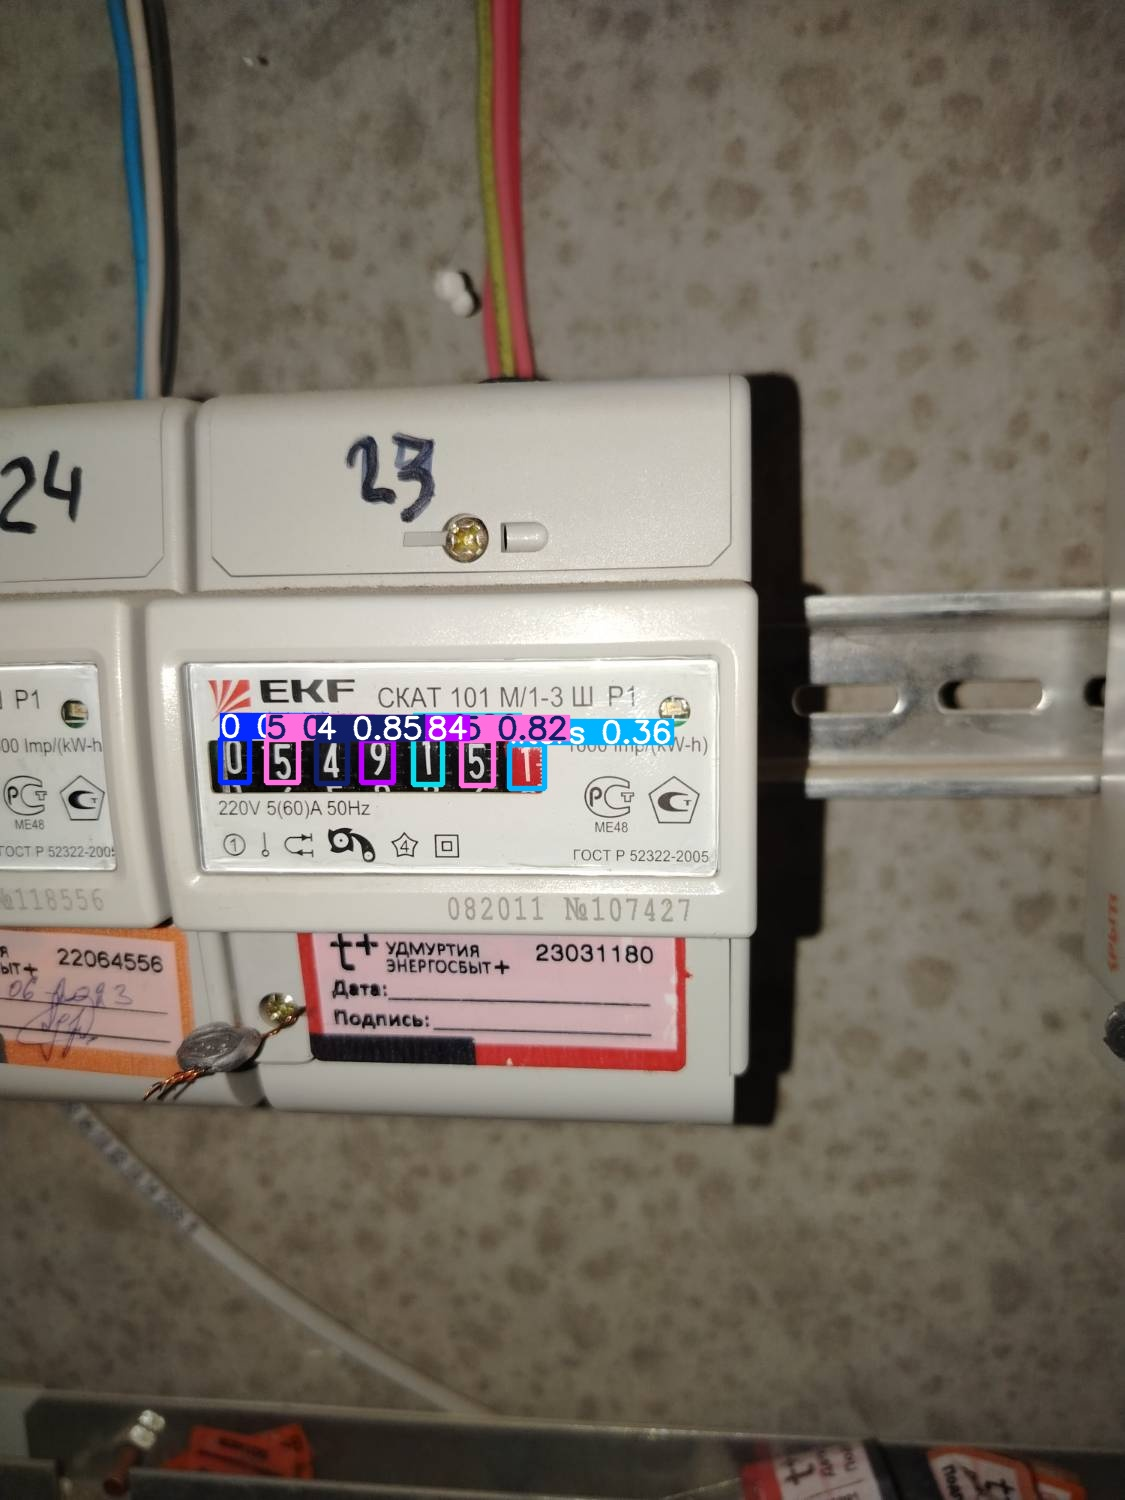


🖼️  20260513_074105.jpg


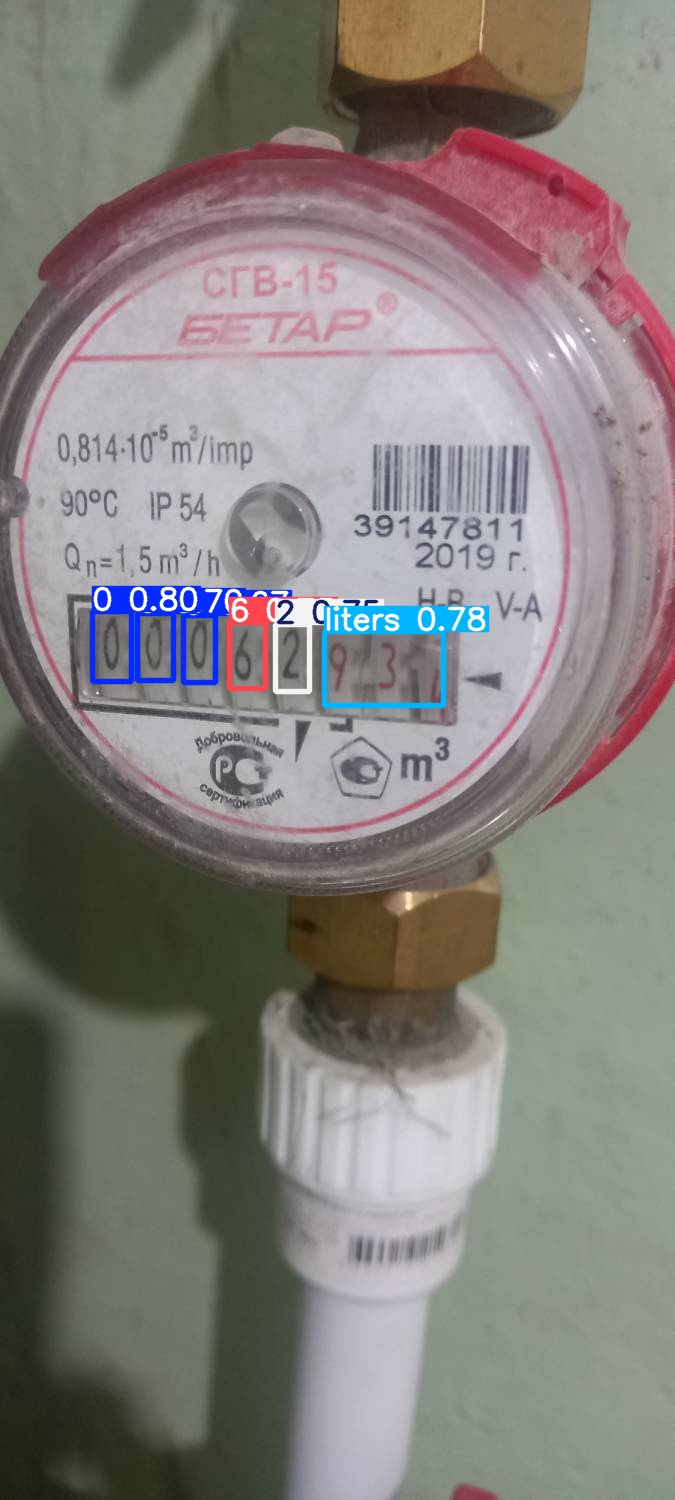


🖼️  20260515_125929.jpg


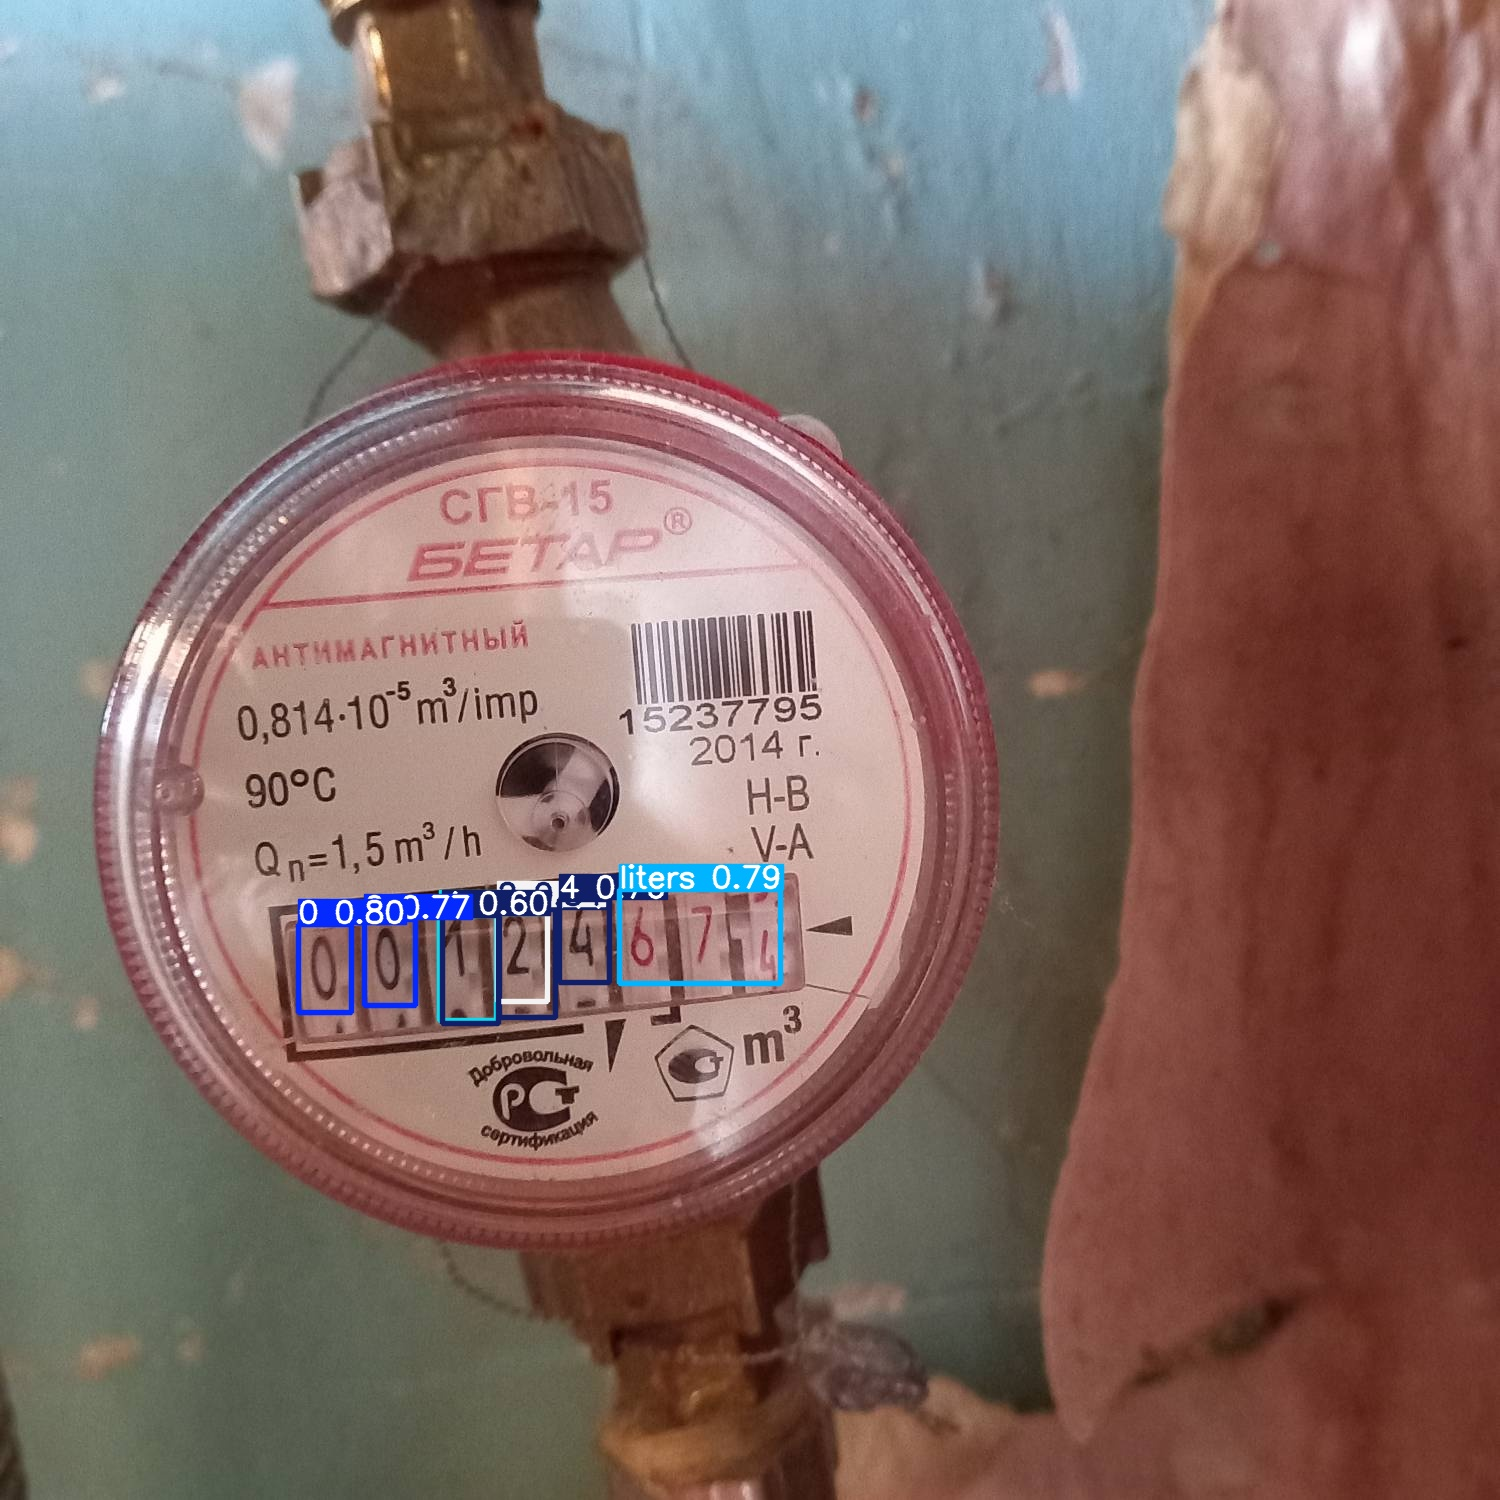


🖼️  IMG_20260506_224224_crop.jpg


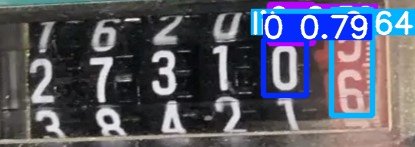


🖼️  IMG_20260518_104045_303.jpg


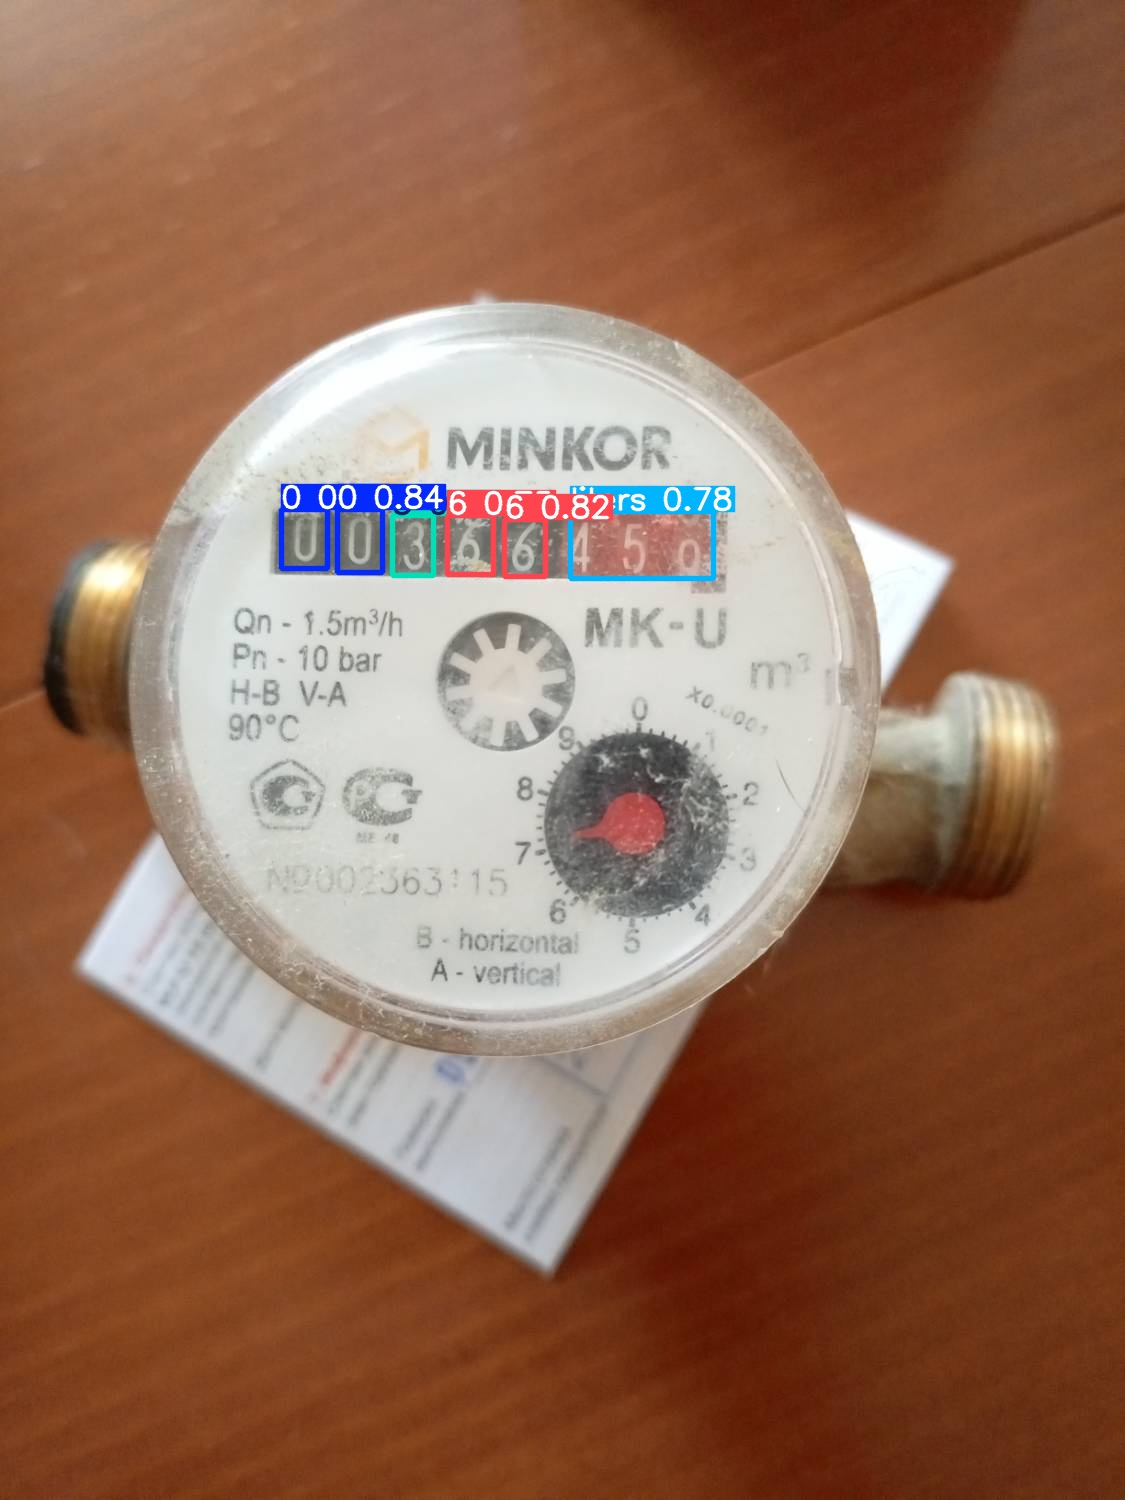


🖼️  IMG_3296.jpg


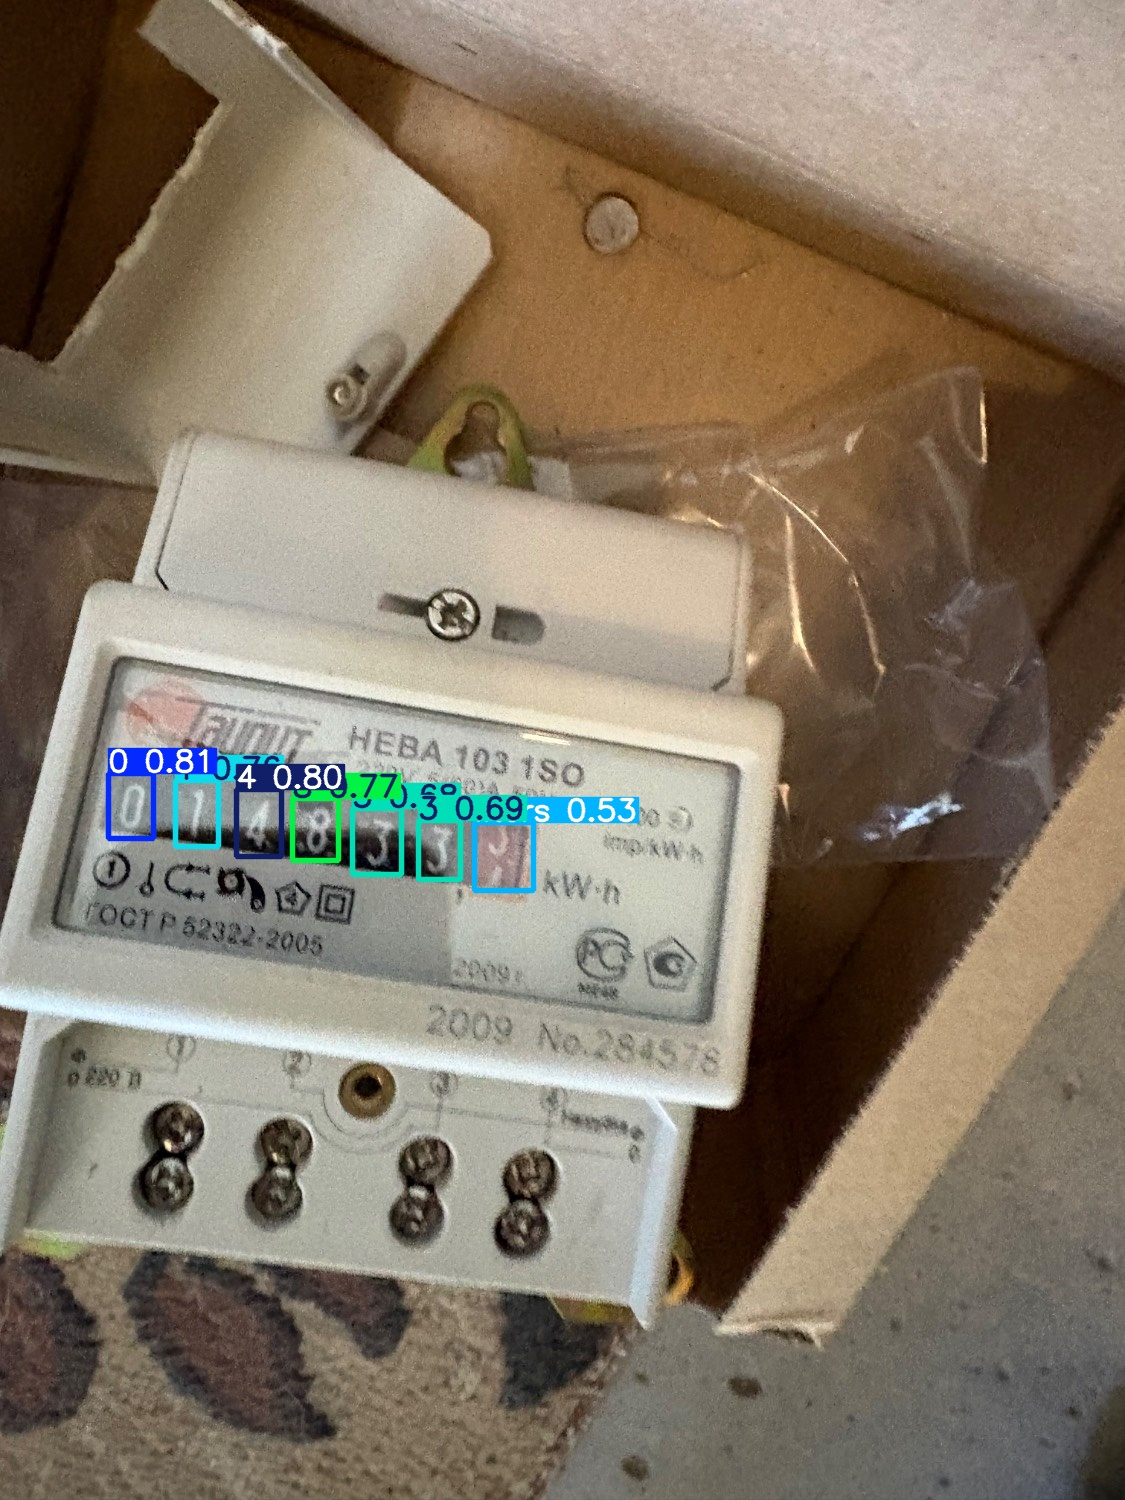


🖼️  K3gh7LEmyHRP9GrRiRSJPizcS0T-n2VzoXdera4zKBDyaQVGdI90hDFrKObYYSy0tsPRfaD5zvjlNFJFYgriaEV01.jpg


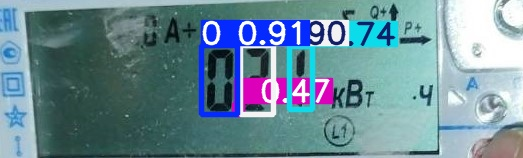


🖼️  Заводск 39-157 (1).jpg


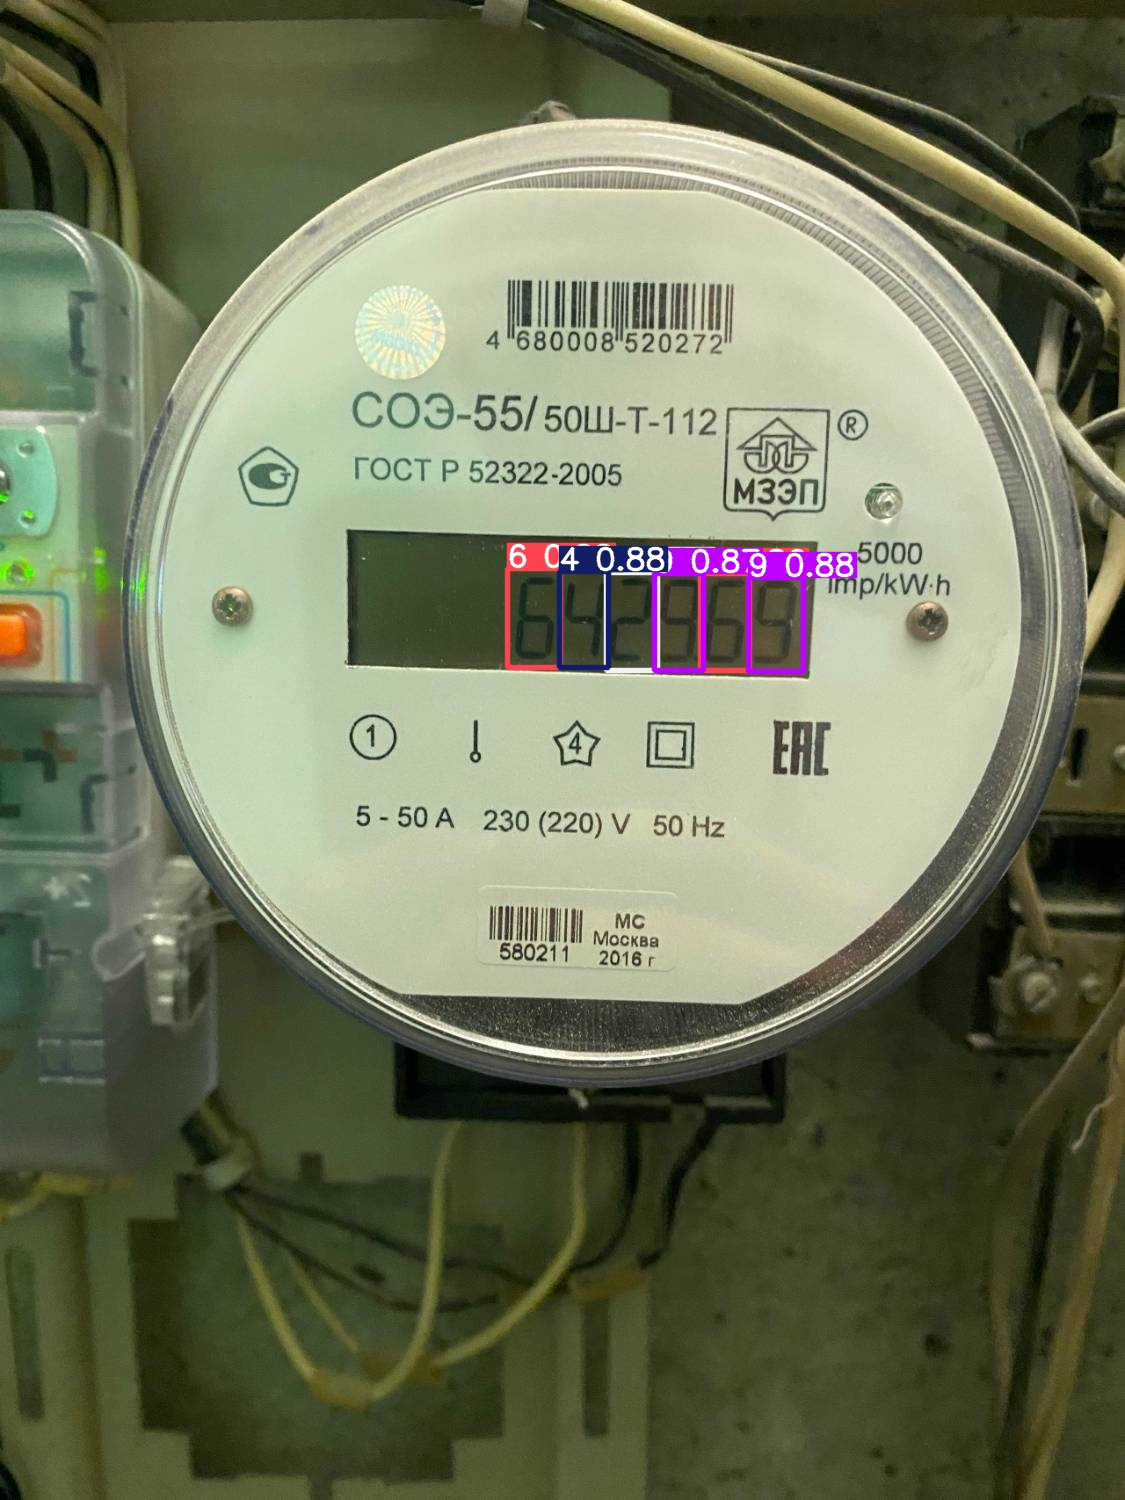


🖼️  Заводск 39-157 (2).jpg


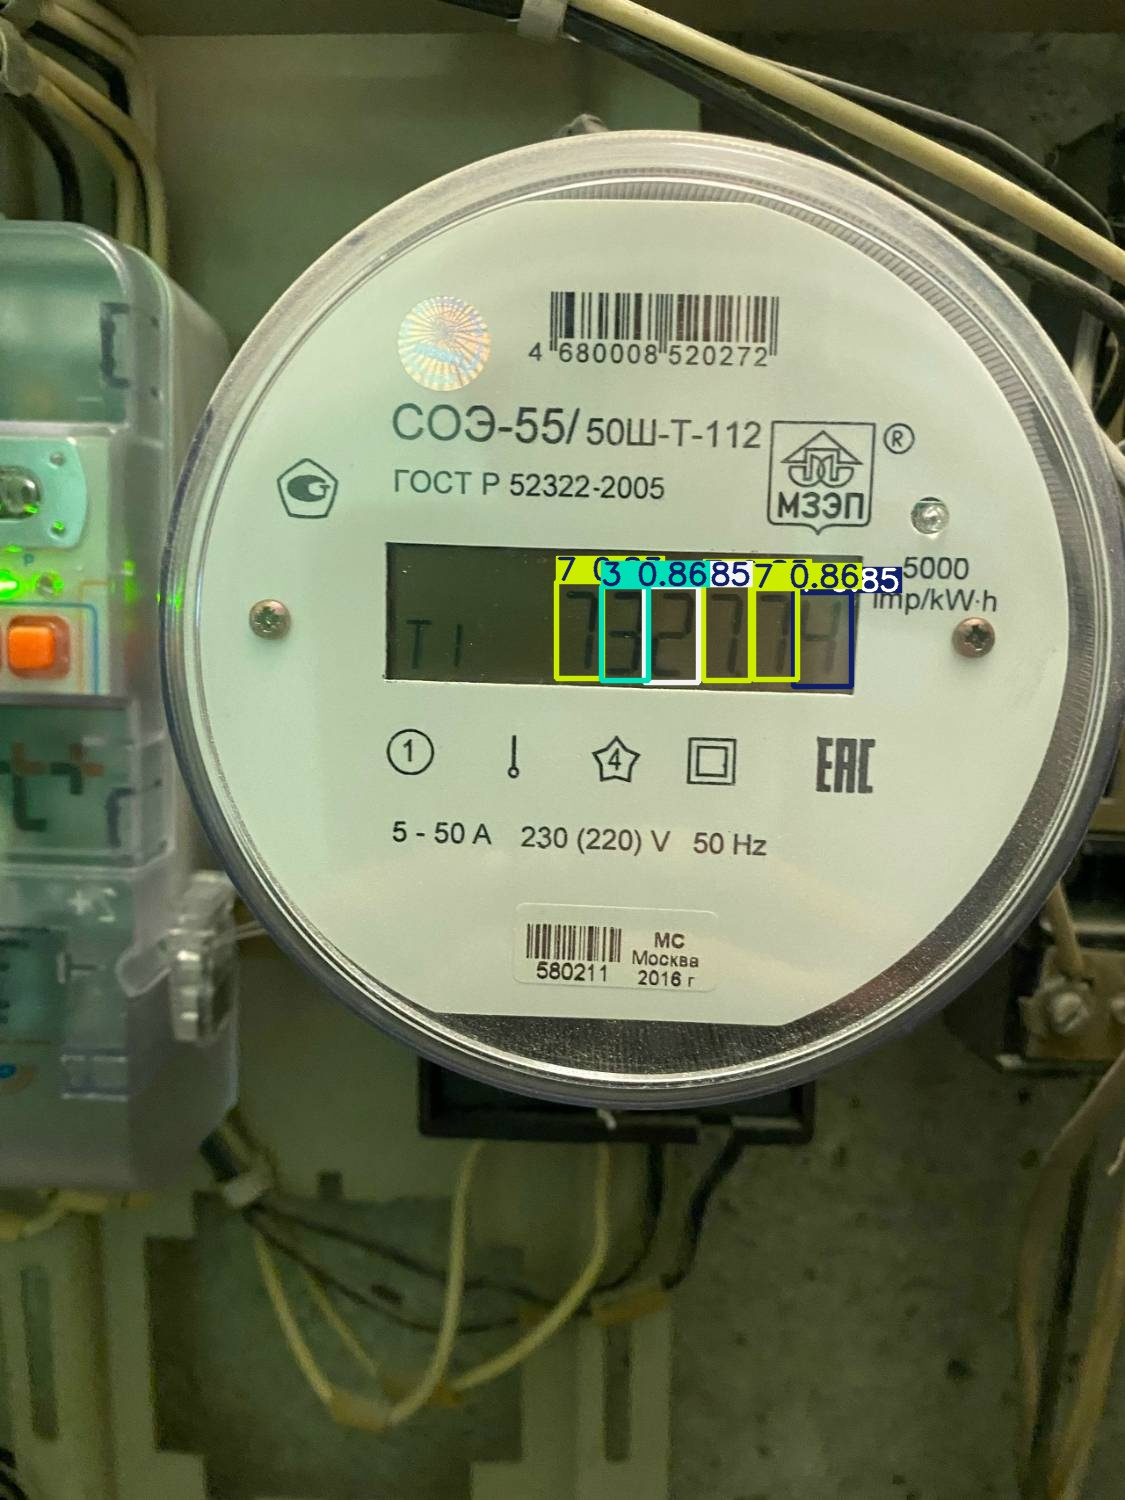

In [ ]:
!python detect.py \
  --weights runs/train/meter_combined_v2/weights/best.pt \
  --source /content/test_photos \
  --img 640 \
  --conf 0.25 \
  --save-txt \
  --save-conf \
  --name meter_test_v2 \
  --exist-ok
# Показать результаты
from IPython.display import Image, display
import glob

result_imgs = sorted(glob.glob('runs/detect/meter_test_v2/*.jpg'))
for img in result_imgs:
    print(f"\n🖼️  {os.path.basename(img)}")
    display(Image(filename=img))

In [ ]:
import shutil
import os

dir = '/content/test_data'
os.makedirs(dir, exist_ok=True)
os.makedirs(f'{dir}/test_photos', exist_ok=True)
os.makedirs(f'{dir}/detect', exist_ok=True)

photos = '/content/test_photos'

# Use shutil.copytree to copy directories
shutil.copytree(photos, f'{dir}/test_photos', dirs_exist_ok=True)

shutil.copytree(f'/content/yolov5/runs/detect', f'{dir}/detect', dirs_exist_ok=True)

'/content/test_data/detect'

In [ ]:
import shutil
import os

# Создаём папку с итоговыми артефактами
final_dir = '/content/yolov5_meter_v2_final'
os.makedirs(final_dir, exist_ok=True)
os.makedirs(f'{final_dir}/weights', exist_ok=True)
os.makedirs(f'{final_dir}/training', exist_ok=True)
os.makedirs(f'{final_dir}/validation', exist_ok=True)
os.makedirs(f'{final_dir}/detection_tests', exist_ok=True)

src_train = 'runs/train/meter_combined_v2'

# 1. Только best.pt и last.pt из весов (без всех epochN.pt)
shutil.copy(f'{src_train}/weights/best.pt', f'{final_dir}/weights/best.pt')
shutil.copy(f'{src_train}/weights/last.pt', f'{final_dir}/weights/last.pt')

# 2. Графики и метрики обучения (всё кроме events.tfevents и epochN.pt)
training_files = [
    'confusion_matrix.png',
    'F1_curve.png',
    'P_curve.png',
    'PR_curve.png',
    'R_curve.png',
    'results.png',
    'results.csv',
    'labels.jpg',
    'labels_correlogram.jpg',
    'hyp.yaml',
    'opt.yaml',
    'train_batch0.jpg',
    'train_batch1.jpg',
    'train_batch2.jpg',
    'val_batch0_labels.jpg',
    'val_batch0_pred.jpg',
    'val_batch1_labels.jpg',
    'val_batch1_pred.jpg',
    'val_batch2_labels.jpg',
    'val_batch2_pred.jpg',
]
for f in training_files:
    src_file = f'{src_train}/{f}'
    if os.path.exists(src_file):
        shutil.copy(src_file, f'{final_dir}/training/{f}')

# 3. Валидация (на test set) — если запускали val.py
src_val = 'runs/val/exp'
if os.path.exists(src_val):
    for item in os.listdir(src_val):
        item_path = f'{src_val}/{item}'
        if os.path.isfile(item_path):
            shutil.copy(item_path, f'{final_dir}/validation/{item}')

# 4. Детекции на твоих 5 проблемных фото
src_detect = 'runs/detect/meter_test_v2'
if os.path.exists(src_detect):
    for item in os.listdir(src_detect):
        item_path = f'{src_detect}/{item}'
        if os.path.isfile(item_path):
            shutil.copy(item_path, f'{final_dir}/detection_tests/{item}')
        elif os.path.isdir(item_path):
            shutil.copytree(item_path, f'{final_dir}/detection_tests/{item}',
                          dirs_exist_ok=True)

# 5. TFLite если есть
tflite_path = f'{src_train}/weights/best-fp16.tflite'
if os.path.exists(tflite_path):
    shutil.copy(tflite_path, f'{final_dir}/weights/best-fp16.tflite')

# Запаковываем в архив
shutil.make_archive('/content/yolov5_meter_v2_final', 'zip', final_dir)

# Размер
size_mb = os.path.getsize('/content/yolov5_meter_v2_final.zip') / 1024 / 1024
print(f"📦 Архив готов: {size_mb:.1f} MB")
print(f"📁 Содержимое:")
!ls -lh /content/yolov5_meter_v2_final.zip
print("\nСтруктура:")
!find /content/yolov5_meter_v2_final -type f | head -50

📦 Архив готов: 47.0 MB
📁 Содержимое:
-rw-r--r-- 1 root root 48M May 18 09:37 /content/yolov5_meter_v2_final.zip

Структура:
/content/yolov5_meter_v2_final/training/hyp.yaml
/content/yolov5_meter_v2_final/training/val_batch0_labels.jpg
/content/yolov5_meter_v2_final/training/results.png
/content/yolov5_meter_v2_final/training/val_batch2_pred.jpg
/content/yolov5_meter_v2_final/training/opt.yaml
/content/yolov5_meter_v2_final/training/P_curve.png
/content/yolov5_meter_v2_final/training/confusion_matrix.png
/content/yolov5_meter_v2_final/training/results.csv
/content/yolov5_meter_v2_final/training/val_batch2_labels.jpg
/content/yolov5_meter_v2_final/training/labels.jpg
/content/yolov5_meter_v2_final/training/PR_curve.png
/content/yolov5_meter_v2_final/training/val_batch1_labels.jpg
/content/yolov5_meter_v2_final/training/R_curve.png
/content/yolov5_meter_v2_final/training/labels_correlogram.jpg
/content/yolov5_meter_v2_final/training/train_batch1.jpg
/content/yolov5_meter_v2_final/training

In [ ]:
from google.colab import files
files.download('/content/yolov5_meter_v2_final.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Экспорт в TFLite для Android

**Важно:** input size в экспорте должен совпадать с тем, что мы будем использовать в Android. У нас в Java-коде сейчас стоит `INPUT_SIZE = 320`, но мы обучили на 416. Есть два варианта:

**Вариант A** — экспортировать с `--imgsz 416`, изменить `INPUT_SIZE = 416` в `YOLOv5MeterRecognition.java`. **Рекомендую**.

**Вариант B** — экспортировать с `--imgsz 320`. Модель сожмёт всё до 320×320 при инференсе, эффект от обучения на 416 частично потеряется.

Ниже — Вариант A.

In [ ]:
# Установим зависимости для экспорта
!pip install tensorflow==2.13.0 -q
!pip install onnx onnx-tf -q

!python export.py \
  --weights runs/train/meter_combined_v2/weights/best.pt \
  --include tflite \
  --img 416

print("\n✅ Экспорт завершён")
!ls -lh runs/train/meter_combined_v2/weights/

ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.6/186.6 kB 21.2 MB/s eta 0:00:00
export: data=data/coco128.yaml, weights=['runs/train/meter_combined_v2/weights/best.pt'], imgsz=[416], batch_size=1, device=cpu, half=False, inplace=False, keras=False, optimize=False, int8=False, per_tensor=False, dynamic=False, cache=, simplify=False, mlmodel=False, opset=17, verbose=False, workspace=4, nms=False, agnostic_nms=False, topk_per_class=100, topk_all=100, iou_thres=0.45, conf_thres=0.25, include=['tflite']
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CPU


In [ ]:
# Скачать результаты
from google.colab import files

weights_dir = "runs/train/meter_combined_v2/weights"

print("📥 Скачиваем TFLite модель...")
files.download(f"{weights_dir}/best-fp16.tflite")

print("📥 Скачиваем PyTorch модель (на случай если понадобится дообучать)...")
files.download(f"{weights_dir}/best.pt")

print("📥 Скачиваем графики обучения...")
files.download("runs/train/meter_combined_v2/results.png")

print("📥 Скачиваем confusion matrix...")
files.download("runs/train/meter_combined_v2/confusion_matrix.png")

print("\n✅ Всё скачано!")

## 13. Что обновить в Android-приложении после получения новой модели

1. **Замени файл** `cordova/www/yolov5_meter.tflite` на новый `best-fp16.tflite` (переименуй).
2. **Открой `YOLOv5MeterRecognition.java`** и измени:
   ```java
   private static final int INPUT_SIZE = 416;  // было 320
   ```
3. **Проверь output shape**. Новая модель на input 416 имеет другое количество detection boxes:
   - 320×320 → 6300 боксов
   - 416×416 → 10647 боксов
   
   В Java коде:
   ```java
   float[][][] output = new float[1][10647][17];  // было [1][6300][17]
   ```
4. **Пересобери apk** (или просто запусти из Android Studio с обновлённым tflite в `assets/www/`).
5. **Тест** на тех же 5 проблемных фото.

In [ ]:
import shutil
from google.colab import files
import os

# Define the directory to be zipped
dir_to_zip = '/content/test_data'

# Define the output path for the zip file (without .zip extension)
output_zip_name = '/content/test_data_archive'

# Create a zip archive of the directory
shutil.make_archive(output_zip_name, 'zip', dir_to_zip)

# Provide a download link for the zip file
print(f"✅ The folder '{dir_to_zip}' has been zipped to '{output_zip_name}.zip'.")
print("📥 Downloading the zip file...")
files.download(f'{output_zip_name}.zip')

✅ The folder '/content/test_data' has been zipped to '/content/test_data_archive.zip'.
📥 Downloading the zip file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>